In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('data/titanic.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])
df.dtypes

Number of rows: 891
Number of columns: 12


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [12]:
# Calculate the mean of all numeric columns
df[df.select_dtypes('number').columns].mean(axis=0)


PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.699118
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

In [ ]:
# median of all numeric columns
df[df.select_dtypes('number').columns].median(axis=0)

PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

In [24]:
# Calculate the number of unique values in each column type 'object'
df[df.select_dtypes('object').columns].nunique(axis=0)

Name        891
Sex           2
Ticket      681
Cabin       147
Embarked      3
dtype: int64

In [26]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [27]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [28]:
df.groupby('Embarked')['Survived'].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [29]:
pd.pivot_table(df, values='Survived', index='Sex', columns='Pclass',aggfunc='mean')

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [30]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [33]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [ ]:
#example codes for handling missing values
#df['Age'].fillna(df['Age'].median(), inplace=True)
#df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
#df.drop(columns=['Cabin'], inplace=True)

In [4]:
import matplotlib.pyplot as plt

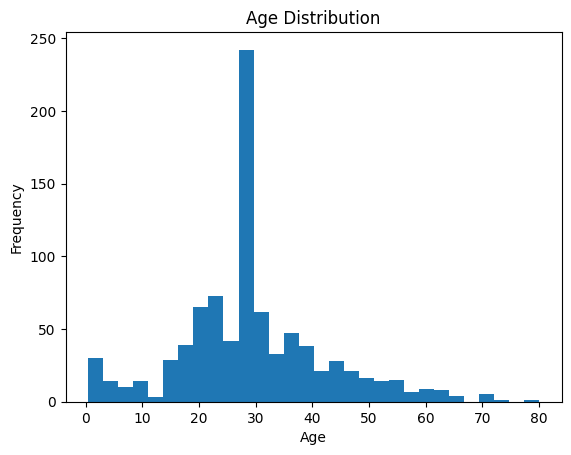

In [36]:

plt.hist(df['Age'], bins=30)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [6]:
import seaborn as sns

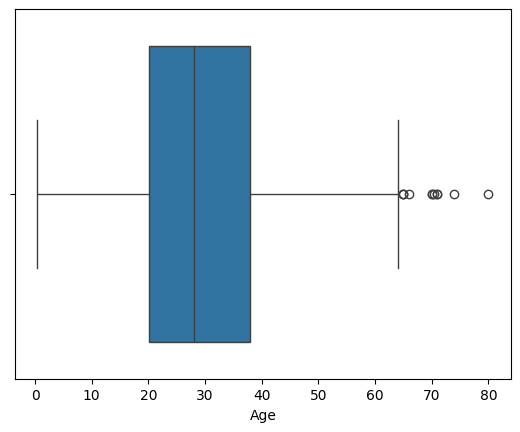

In [11]:
sns.boxplot(x=df['Age'])
plt.show()

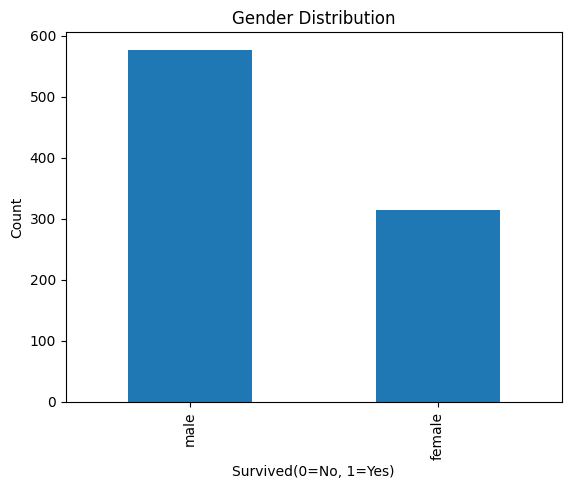

In [13]:
df['Sex'].value_counts().plot(kind='bar')
plt.title('Gender Distribution')
plt.xlabel('Survived(0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

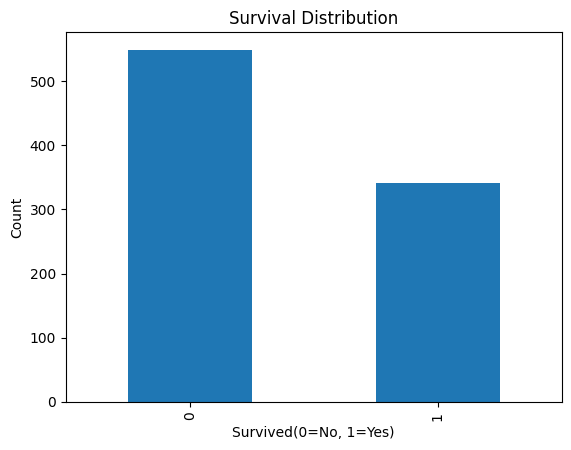

In [5]:
df['Survived'].value_counts().plot(kind='bar')
plt.title('Survival Distribution')
plt.xlabel('Survived(0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

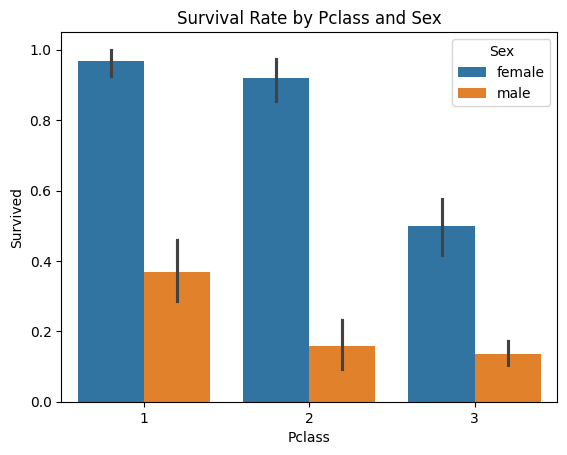

In [9]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.title('Survival Rate by Pclass and Sex')
plt.show()

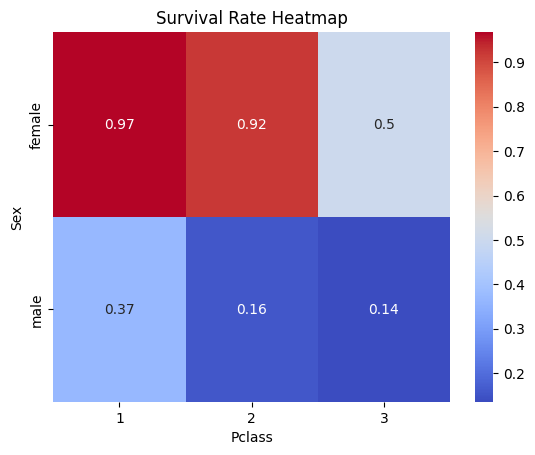

In [12]:
pivot=pd.pivot_table(df, values='Survived', index='Sex', columns='Pclass',aggfunc='mean')
sns.heatmap(pivot, annot=True, cmap='coolwarm')
plt.title('Survival Rate Heatmap')
plt.show()

In [ ]:
df['Survived'].mean()*100
#around 38 percent survived

np.float64(38.38383838383838)

In [ ]:
df.groupby('Pclass')['Survived'].mean()
#higher Pclass had higher survival rates

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [ ]:
df.groupby('Sex')['Survived'].mean()
#females had higher survival rates

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [ ]:
df.groupby(pd.cut(df['Age'], bins=[0,12,20,40,60,80]))['Survived'].mean()
#children had higher survival rates

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11532\588409060.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['Age'], bins=[0,12,20,40,60,80]))['Survived'].mean()


Age
(0, 12]     0.579710
(12, 20]    0.381818
(20, 40]    0.397403
(40, 60]    0.390625
(60, 80]    0.227273
Name: Survived, dtype: float64

In [27]:
df.drop_duplicates(inplace=True)

In [28]:
df['Age'].fillna(df['Age'].median(),  inplace=True)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11532\359363315.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(),  inplace=True)


In [29]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [30]:
df['Sex']=df['Sex'].map({'male':0, 'female':1})

In [32]:
df=pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [33]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,False,True
